# The KV Cache

In notebook 01 we saw that generation is an autoregressive loop — the model predicts one token
at a time, appending each to the input before running the next forward pass.

The naive approach recomputes attention over the **entire** sequence every step. As the sequence
grows, each step gets slower — O(n²) in sequence length. The **KV cache** eliminates this
redundant computation.

We'll cover:
1. The problem — manual token-by-token generation without caching
2. Measuring the degradation as sequence length grows
3. The KV cache — what it stores and why it helps
4. Prefill vs decode — the two phases of inference

In [1]:
import os
os.environ["NO_PROXY"] = "localhost,127.0.0.1"
os.environ["no_proxy"] = "localhost,127.0.0.1"

import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

In [2]:
MODEL_NAME = "Qwen/Qwen3.5-2B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16, device_map="auto")

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

## 1. The problem — naive generation without a cache

Let's generate tokens the slow way: each step, we feed the **entire** sequence (prompt + all
previously generated tokens) through the full model. No shortcuts.

Watch how the time per token increases as the sequence gets longer.

In [3]:
prompt = "Explain the concept of attention in neural networks step by step."
messages = [{"role": "user", "content": prompt}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
input_ids = tokenizer(text, return_tensors="pt").to(model.device)

print(f"Prompt length: {input_ids['input_ids'].shape[1]} tokens")
print(f"Device: {input_ids['input_ids'].device}")

Prompt length: 25 tokens
Device: mps:0


In [4]:
# Naive generation: full forward pass every step (NO cache)
num_tokens_to_generate = 50
generated_ids = input_ids["input_ids"].clone()
times_no_cache = []

print(f"{'Step':<6} {'Seq len':<10} {'Time (ms)':<12}")
print("-" * 28)

for i in range(num_tokens_to_generate):
    start = time.perf_counter()
    
    with torch.no_grad():
        outputs = model(generated_ids)  # full sequence every time!
    
    next_token_id = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)  # [1, 1]
    generated_ids = torch.cat([generated_ids, next_token_id], dim=-1)
    
    elapsed = (time.perf_counter() - start) * 1000
    times_no_cache.append(elapsed)
    
    if i % 10 == 0 or i == num_tokens_to_generate - 1:
        print(f"{i:<6} {generated_ids.shape[1]:<10} {elapsed:<12.1f}")

print(f"\nTotal: {sum(times_no_cache):.0f} ms for {num_tokens_to_generate} tokens")
print(f"Average: {sum(times_no_cache)/len(times_no_cache):.1f} ms/token")

Step   Seq len    Time (ms)   
----------------------------
0      26         286.0       
10     36         107.6       
20     46         106.9       
30     56         130.3       
40     66         283.4       
49     75         146.7       

Total: 6288 ms for 50 tokens
Average: 125.8 ms/token


### Why it gets slower

Each attention layer computes:
```
Attention(Q, K, V) = softmax(Q @ K.T / √d) @ V
```

When the sequence has `n` tokens:
- `Q` is `[n, d]`, `K` is `[n, d]` → `Q @ K.T` is `[n, n]` — **quadratic** in sequence length
- Every time we add a token, we recompute ALL of Q, K, V from scratch

But here's the key insight: **the K and V values for previous tokens don't change**.
Token 5's key/value vectors are the same whether the sequence is 10 or 100 tokens long.
We're recomputing them for nothing.

## 2. The KV cache — cache what doesn't change

The KV cache stores the key and value vectors for all previously processed tokens.
On each new step, we only compute Q, K, V for the **new token** and append K, V to the cache.

```
Without cache (step n):  compute Q, K, V for ALL n tokens     → O(n²)
With cache (step n):     compute Q, K, V for 1 new token only → O(n) per step
                         reuse cached K, V for tokens 1..n-1
```

The forward pass now only processes 1 token, but attends to the full cached history.

In [5]:
# Generation WITH KV cache
generated_ids_cached = input_ids["input_ids"].clone()
times_with_cache = []
past_key_values = None
next_token_id = None

print(f"{'Step':<6} {'Seq len':<10} {'Time (ms)':<12} {'Input size':<12}")
print("-" * 40)

for i in range(num_tokens_to_generate):
    start = time.perf_counter()
    
    with torch.no_grad():
        if past_key_values is None:
            # First call: process the full prompt (this is "prefill")
            outputs = model(generated_ids_cached, use_cache=True)
            input_for_step = generated_ids_cached
        else:
            # Subsequent calls: only feed the NEW token
            outputs = model(next_token_id, past_key_values=past_key_values, use_cache=True)
            input_for_step = next_token_id
    
    past_key_values = outputs.past_key_values
    next_token_id = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)  # [1, 1]
    generated_ids_cached = torch.cat([generated_ids_cached, next_token_id], dim=-1)
    
    elapsed = (time.perf_counter() - start) * 1000
    times_with_cache.append(elapsed)
    
    if i % 10 == 0 or i == num_tokens_to_generate - 1:
        print(f"{i:<6} {generated_ids_cached.shape[1]:<10} {elapsed:<12.1f} {input_for_step.shape[1]:<12}")

print(f"\nTotal: {sum(times_with_cache):.0f} ms for {num_tokens_to_generate} tokens")
print(f"Average: {sum(times_with_cache)/len(times_with_cache):.1f} ms/token")

Step   Seq len    Time (ms)    Input size  
----------------------------------------
0      26         117.6        25          
10     36         24.1         1           
20     46         25.1         1           
30     56         24.7         1           
40     66         25.0         1           
49     75         23.9         1           

Total: 1450 ms for 50 tokens
Average: 29.0 ms/token


## 3. Comparison — the speedup

Let's plot the time per token for both approaches side by side.

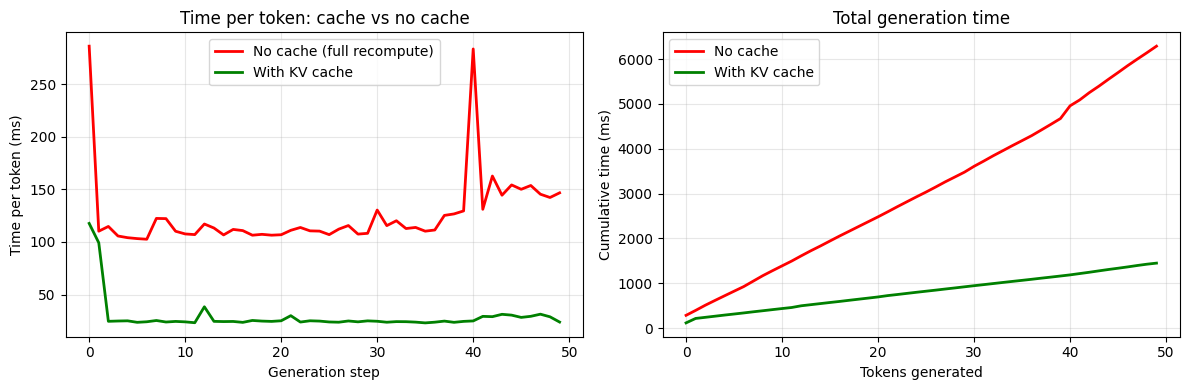


Speedup: 4.3x faster with KV cache


In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Time per token
ax1.plot(times_no_cache, label="No cache (full recompute)", color="red", linewidth=2)
ax1.plot(times_with_cache, label="With KV cache", color="green", linewidth=2)
ax1.set_xlabel("Generation step")
ax1.set_ylabel("Time per token (ms)")
ax1.set_title("Time per token: cache vs no cache")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cumulative time
import numpy as np
ax2.plot(np.cumsum(times_no_cache), label="No cache", color="red", linewidth=2)
ax2.plot(np.cumsum(times_with_cache), label="With KV cache", color="green", linewidth=2)
ax2.set_xlabel("Tokens generated")
ax2.set_ylabel("Cumulative time (ms)")
ax2.set_title("Total generation time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

speedup = sum(times_no_cache) / sum(times_with_cache)
print(f"\nSpeedup: {speedup:.1f}x faster with KV cache")

## 4. Prefill vs Decode — the two phases of inference

With the KV cache, inference naturally splits into two distinct phases:

### Prefill (prompt processing)
- Processes the **entire prompt** in one forward pass
- All tokens are processed in parallel (they're all known upfront)
- Populates the KV cache with key/value vectors for every prompt token
- **Compute-bound**: large matrix multiplies, high GPU utilization
- Time scales linearly with prompt length (parallelism hides the quadratic attention cost)

### Decode (token generation)
- Generates tokens **one at a time**
- Each step: 1 new token in, 1 new token out
- Only computes Q, K, V for the single new token
- Appends new K, V to the cache; attends over full cached history
- **Memory-bound**: small compute, but must read the entire KV cache from memory
- Time per token is roughly constant (doesn't grow with sequence length)

```
┌──────────────────────────────────┐  ┌──────────────────────────────────┐
│          PREFILL                 │  │          DECODE (× N)            │
├──────────────────────────────────┤  ├──────────────────────────────────┤
│  Input: full prompt (P tokens)   │  │  Input: 1 new token             │
│  Output: first generated token   │  │  Output: 1 next token           │
│  + KV cache populated            │  │  + KV cache updated             │
│                                  │  │                                  │
│  Compute: O(P² × d)             │  │  Compute: O(S × d) per step     │
│  Bottleneck: COMPUTE             │  │  Bottleneck: MEMORY bandwidth   │
│  GPU util: HIGH                  │  │  GPU util: LOW                  │
└──────────────────────────────────┘  └──────────────────────────────────┘
         (one pass)                          (repeated per token)
```

This distinction is why LLM serving systems optimize these phases separately:
- **Prefill** benefits from tensor parallelism and batching
- **Decode** benefits from memory bandwidth, quantized KV caches, and speculative decoding

In [7]:
# Let's measure prefill vs decode separately
print("=" * 50)
print("PREFILL vs DECODE timing")
print("=" * 50)

prompt_ids = input_ids["input_ids"]

# Prefill
start = time.perf_counter()
with torch.no_grad():
    outputs = model(prompt_ids, use_cache=True)
prefill_time = (time.perf_counter() - start) * 1000
prefill_cache = outputs.past_key_values

print(f"\nPrefill:")
print(f"  Tokens processed: {prompt_ids.shape[1]}")
print(f"  Time: {prefill_time:.1f} ms")
print(f"  Throughput: {prompt_ids.shape[1] / prefill_time * 1000:.0f} tokens/sec")

# Decode (10 steps)
decode_times = []
cache = prefill_cache
token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)  # [1, 1]

for _ in range(10):
    start = time.perf_counter()
    with torch.no_grad():
        out = model(token, past_key_values=cache, use_cache=True)
    decode_times.append((time.perf_counter() - start) * 1000)
    cache = out.past_key_values
    token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)  # [1, 1]

avg_decode = sum(decode_times) / len(decode_times)
print(f"\nDecode:")
print(f"  Tokens generated: {len(decode_times)}")
print(f"  Avg time per token: {avg_decode:.1f} ms")
print(f"  Throughput: {1000 / avg_decode:.0f} tokens/sec")
print(f"\nPrefill processes {prompt_ids.shape[1] / (prefill_time / avg_decode):.1f}x more tokens")
print(f"per unit time than decode (parallel vs sequential).")

PREFILL vs DECODE timing

Prefill:
  Tokens processed: 25
  Time: 93.4 ms
  Throughput: 268 tokens/sec

Decode:
  Tokens generated: 10
  Avg time per token: 22.0 ms
  Throughput: 45 tokens/sec

Prefill processes 5.9x more tokens
per unit time than decode (parallel vs sequential).


## 5. What's inside the KV cache?

The cache stores K and V tensors for each layer. Let's inspect its shape to understand
the memory cost.

In [8]:
# Inspect the KV cache structure
# Qwen3.5 uses a hybrid cache: DynamicLayer (full attention) + LinearAttentionLayer
print(f"Number of cached layers: {len(prefill_cache)}")
print(f"\nCache layer types:")
for i, layer in enumerate(prefill_cache.layers):
    layer_type = type(layer).__name__
    if i < 4 or i == len(prefill_cache.layers) - 1:
        print(f"  Layer {i:2d}: {layer_type}")
    elif i == 4:
        print(f"  ...")

# Inspect a full-attention layer (every 4th layer: 3, 7, 11, ...)
full_attn_layer = prefill_cache.layers[3]
print(f"\nFull-attention layer (layer 3) - traditional KV cache:")
print(f"  Keys shape:   {full_attn_layer.keys[0].shape}  (num_kv_heads, seq_len, head_dim)")
print(f"  Values shape: {full_attn_layer.values[0].shape}")

# Inspect a linear-attention layer (recurrent state, not KV pairs)
linear_layer = prefill_cache.layers[0]
print(f"\nLinear-attention layer (layer 0) - recurrent state:")
if isinstance(getattr(linear_layer, 'recurrent_states', None), torch.Tensor):
    print(f"  Recurrent state shape: {linear_layer.recurrent_states.shape}")
if isinstance(getattr(linear_layer, 'conv_states', None), torch.Tensor):
    print(f"  Conv state shape: {linear_layer.conv_states.shape}")

# Estimate total cache memory
total_bytes = 0
for layer in prefill_cache.layers:
    if hasattr(layer, 'keys') and isinstance(layer.keys, list) and len(layer.keys) > 0:
        for t in layer.keys + layer.values:
            total_bytes += t.numel() * t.element_size()
    if isinstance(getattr(layer, 'recurrent_states', None), torch.Tensor):
        total_bytes += layer.recurrent_states.numel() * layer.recurrent_states.element_size()
    if isinstance(getattr(layer, 'conv_states', None), torch.Tensor):
        total_bytes += layer.conv_states.numel() * layer.conv_states.element_size()

seq_len = prompt_ids.shape[1]
print(f"\nTotal cache memory for {seq_len} tokens: {total_bytes / 1e6:.2f} MB")
print(f"\nNote: Qwen3.5's hybrid design means only 6 of 24 layers use traditional KV caches.")
print(f"The other 18 layers use fixed-size recurrent states — they DON'T grow with sequence length.")
print(f"This is a major memory advantage of the hybrid architecture over pure transformers.")

Number of cached layers: 24

Cache layer types:
  Layer  0: LinearAttentionLayer
  Layer  1: LinearAttentionLayer
  Layer  2: LinearAttentionLayer
  Layer  3: DynamicLayer
  ...
  Layer 23: DynamicLayer

Full-attention layer (layer 3) - traditional KV cache:
  Keys shape:   torch.Size([2, 35, 256])  (num_kv_heads, seq_len, head_dim)
  Values shape: torch.Size([2, 35, 256])

Linear-attention layer (layer 0) - recurrent state:
  Recurrent state shape: torch.Size([1, 16, 128, 128])
  Conv state shape: torch.Size([1, 6144, 4])

Total cache memory for 25 tokens: 10.32 MB

Note: Qwen3.5's hybrid design means only 6 of 24 layers use traditional KV caches.
The other 18 layers use fixed-size recurrent states — they DON'T grow with sequence length.
This is a major memory advantage of the hybrid architecture over pure transformers.


## Summary

| | Without KV cache | With KV cache |
|---|---|---|
| Input per step | Full sequence (growing) | 1 token |
| Compute per step | O(n²) — recompute everything | O(n) — attend over cache |
| Time per token | Grows with sequence length | Roughly constant |
| Memory | Low (no cache stored) | High (all K,V stored) |

**The KV cache trades memory for compute** — and this tradeoff is the foundation of
most LLM serving optimisations:
- **KV cache quantization**: reduce memory per cached token (FP8, INT4)
- **PagedAttention** (vLLM): manage cache memory like virtual memory pages
- **Speculative decoding**: run a small model to draft tokens, verify in batch
- **Multi-Query / Grouped-Query Attention**: fewer KV heads = smaller cache
- **Sliding window attention**: bound cache size by discarding old tokens